<a href="https://colab.research.google.com/github/Merenguimona/act2IA/blob/main/Entrenamiento_y_prueba_de_modelo_sin_redes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#%pip install pandas scikit-learn matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspect
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree

# Configuración visual
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Semilla para reproducibilidad
np.random.seed(42)

In [3]:
url_SocialMediaP = "https://raw.githubusercontent.com/Merenguimona/act2IA/refs/heads/main/Datasets/social_media_productivity_6000.csv"

dt_SocialMediaP = pd.read_csv(url_SocialMediaP, sep= ",")

print("Primeras filas")
dt_SocialMediaP.head()

Primeras filas


,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


In [4]:
dt_SocialMediaP.describe(include="all")

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880,5880.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3064,NaN
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,NaN,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,NaN,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,NaN,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,NaN,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,NaN,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,NaN,58.560000


In [5]:
print("Dimensiones:", dt_SocialMediaP.shape)

print("\nInformación general")
dt_SocialMediaP.info()

print("\nTipos de datos")
print(dt_SocialMediaP.dtypes)

Dimensiones: (6000, 9)

Información general
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   str    
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), str(1)
memory usage: 422.0 KB

Tipos de datos
age                      float64
daily_screen_time        float64
social_media_hours       float64
study_hours              float64
sleep_hours              float64
notifications_per_day    float64
focus_score              

In [6]:
print("Valores nulos por columna")
print(dt_SocialMediaP.isnull().sum())

print("\nDuplicados:", dt_SocialMediaP.duplicated().sum())

Valores nulos por columna
age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64

Duplicados: 0


In [7]:
#Eliminando nulls del dataset.

# Rellenar con la media Valores numericos(float)
dt_SocialMediaP = dt_SocialMediaP.fillna(dt_SocialMediaP.mean(numeric_only=True))

#Rellenar con la moda el addition_level(str)
dt_SocialMediaP["addiction_level"] = dt_SocialMediaP["addiction_level"].fillna(
    dt_SocialMediaP["addiction_level"].mode()[0]
)

print("\nNulos después:")
print(dt_SocialMediaP.isnull().sum())

print("\nTamaño final:")
print(dt_SocialMediaP.shape)


Nulos después:
age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64

Tamaño final:
(6000, 9)


In [8]:
#Transformar todo a numerico para mejor análisis.
le = LabelEncoder()
jerarquia = {"Low": 0, "Medium": 1, "High": 2}

# CAMBIO AQUÍ: Usamos una lista para incluir "object" y "str" explícitamente
for col in dt_SocialMediaP.select_dtypes(include=["object", "str"]).columns:
    if col == "addiction_level":
        dt_SocialMediaP[col] = dt_SocialMediaP[col].map(jerarquia)
    else:
        dt_SocialMediaP[col] = le.fit_transform(dt_SocialMediaP[col])

dt_SocialMediaP.info()
#Valores del addiction_level
dt_SocialMediaP['addiction_level'].unique()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    6000 non-null   float64
 1   daily_screen_time      6000 non-null   float64
 2   social_media_hours     6000 non-null   float64
 3   study_hours            6000 non-null   float64
 4   sleep_hours            6000 non-null   float64
 5   notifications_per_day  6000 non-null   float64
 6   focus_score            6000 non-null   float64
 7   addiction_level        6000 non-null   int64  
 8   productivity_score     6000 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 422.0 KB


array([1, 0, 2])

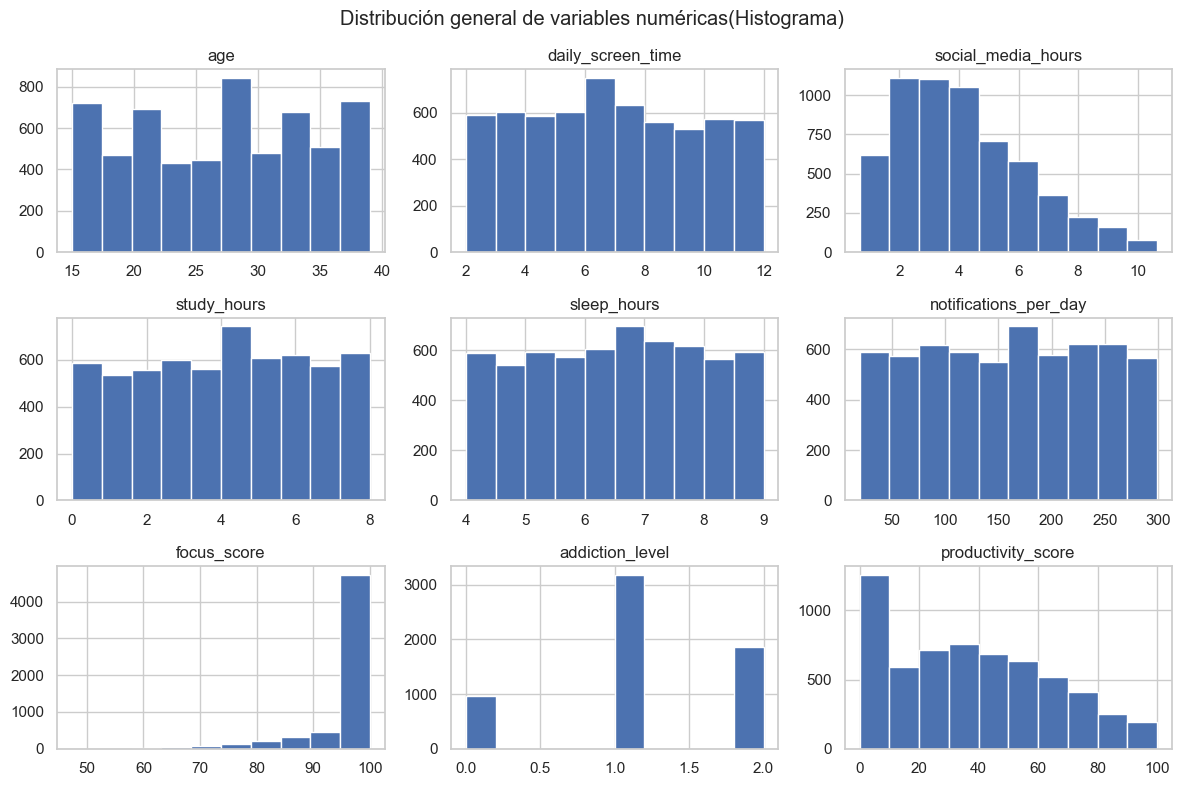

In [9]:
#Histograma
dt_SocialMediaP.hist(figsize=(12,8))
plt.suptitle("Distribución general de variables numéricas(Histograma)")
plt.tight_layout()
plt.show()

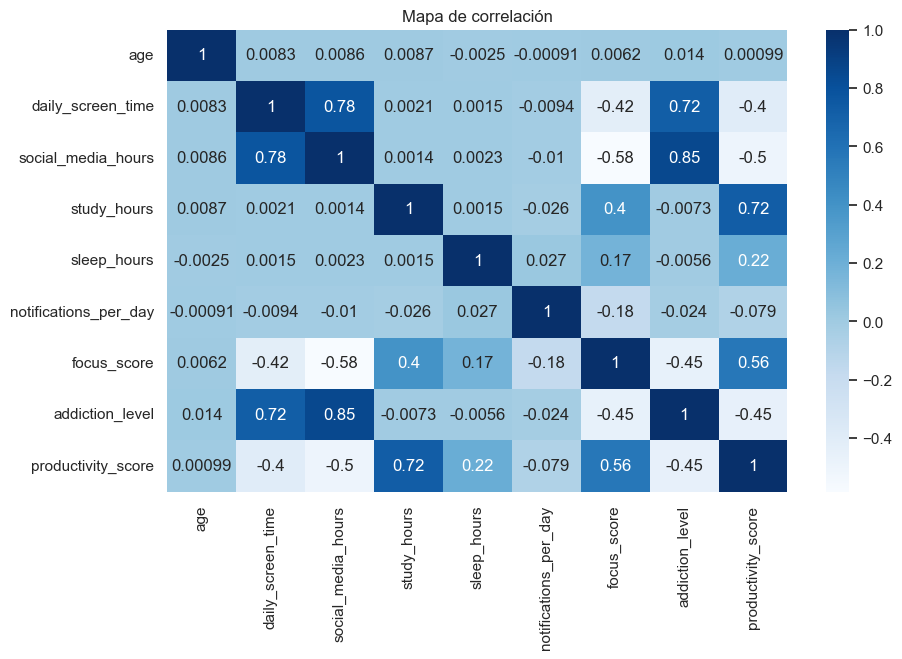

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(
    dt_SocialMediaP.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)
plt.title("Mapa de correlación")
plt.show()

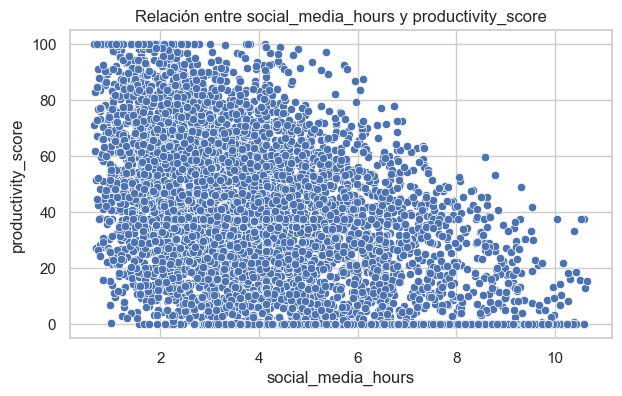

In [11]:
plt.figure(figsize=(7,4))

sns.scatterplot(
    data=dt_SocialMediaP,
    x="social_media_hours",
    y="productivity_score"
)

plt.title("Relación entre social_media_hours y productivity_score")
plt.show()

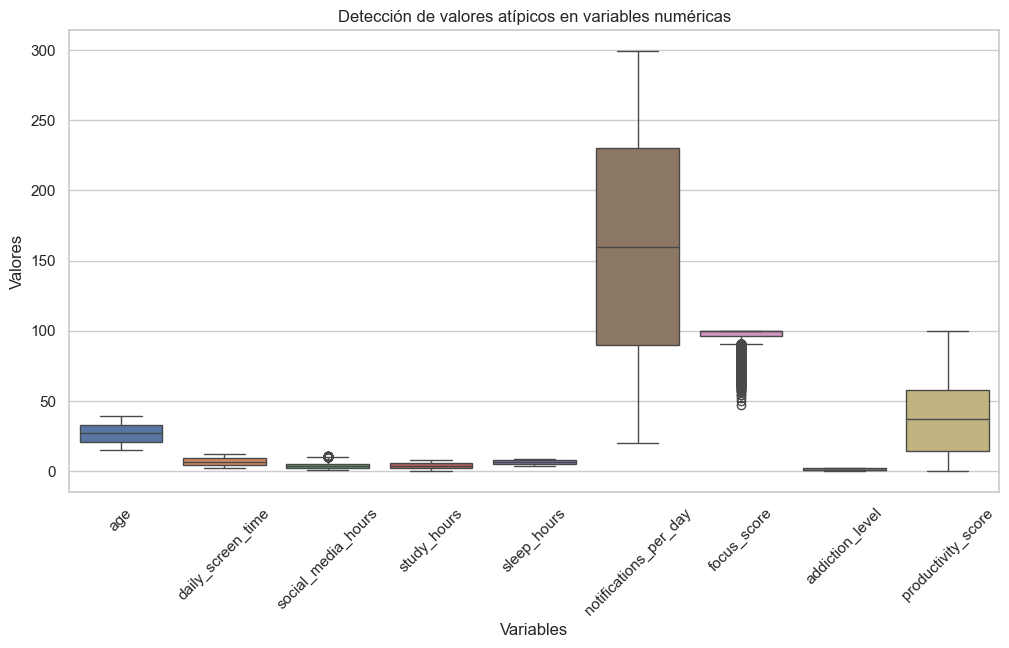

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(data=dt_SocialMediaP.select_dtypes(include="number"))

plt.xticks(rotation=45)
plt.title("Detección de valores atípicos en variables numéricas")
plt.xlabel("Variables")
plt.ylabel("Valores")

plt.show()

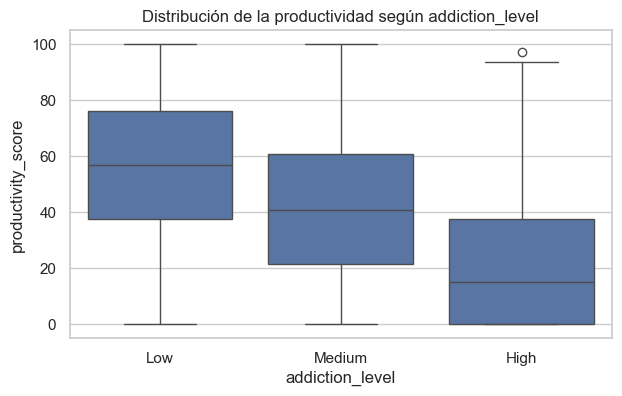

In [13]:
mapa_adiccion = {0: "Low", 1: "Medium", 2: "High"}

dt_SocialMediaP["addiction_level"] = dt_SocialMediaP["addiction_level"].map(mapa_adiccion)

plt.figure(figsize=(7,4))

sns.boxplot(
    data=dt_SocialMediaP,
    x="addiction_level",
    y="productivity_score",
    order=["Low", "Medium", "High"]
)

plt.title("Distribución de la productividad según addiction_level")
plt.show()

## Hallazgos EDA


Durante el análisis exploratorio preliminar se logran observar 2 variables objetivo **productivity_score** y **addiction_level** siendo estas las de mayor relevancia para el conjunto de datos analizado. De igual manera se observó que las variables numéricas presentan distribuciones relativamente estables, con una mayor concentración de registros en rangos medios de *productivity_score* y *focus_score*, lo que sugiere un comportamiento general consistente en los niveles de productividad y enfoque de los usuarios.

El mapa de correlación evidenció una relación negativa entre *social_media_hours* y *productivity_score*, indicando que, a medida que aumentan las horas dedicadas a redes sociales, la productividad tiende a disminuir. De manera complementaria, la variable *sleep_hours* mostró una asociación positiva con *focus_score*, sugiriendo que mayores horas de descanso se relacionan con mejores niveles de concentración.

Finalmente, el gráfico de distribución de la productividad según *addiction_level* permitió identificar que los usuarios con un nivel de adicción alto (High) presentan medianas de productividad más bajas, reforzando la hipótesis de que un mayor grado de dependencia al uso de redes sociales impacta negativamente en el desempeño de las actividades diarias.

# DATASET de Weather History

La variable objetivo seleccionada para el análisis es **Temperature (C)**.

In [14]:
## Obtención de información del segundo Dataset
url_WeatherHist = "https://raw.githubusercontent.com/Merenguimona/act2IA/refs/heads/main/Datasets/weatherHistory.csv"
dt_WeatherHist = pd.read_csv(url_WeatherHist, sep= ",")
print ("Selección de primeras filas para corroborar el cargado del Dataset y analizar el contenido de las columnas")
dt_WeatherHist.head()

Selección de primeras filas para corroborar el cargado del Dataset y analizar el contenido de las columnas


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [15]:
print("Valores nulos por columna")
print(dt_WeatherHist.isnull().sum())

print("\nDuplicados:", dt_WeatherHist.duplicated().sum())

print(dt_WeatherHist.shape)
print(dt_WeatherHist.info())


Valores nulos por columna
Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

Duplicados: 24
(96453, 12)
<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind S

In [16]:
#Eliminando nulls del dataset.
dt_WeatherHist = dt_WeatherHist.dropna()

#Eliminando Duplicados del dataset.
dt_WeatherHist = dt_WeatherHist.drop_duplicates()

print("\nNulos después:")
print(dt_WeatherHist.isnull().sum())

print("\nDuplicados después: ", dt_WeatherHist.duplicated().sum())

print("\nTamaño final:")
print(dt_WeatherHist.shape)



Nulos después:
Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64

Duplicados después:  0

Tamaño final:
(95912, 12)


In [17]:
#Verificando valores unicos de Daily Summary
dt_WeatherHist['Daily Summary'].unique()

<StringArray>
[                            'Partly cloudy throughout the day.',
                             'Mostly cloudy throughout the day.',
                                         'Foggy in the evening.',
                    'Foggy overnight and breezy in the morning.',
                                  'Overcast throughout the day.',
                                    'Partly cloudy until night.',
                                    'Mostly cloudy until night.',
            'Foggy starting overnight continuing until morning.',
                                         'Foggy in the morning.',
                                  'Partly cloudy until evening.',
 ...
             'Overcast throughout the day and breezy overnight.',
                           'Overcast starting in the afternoon.',
 'Partly cloudy throughout the day and breezy in the afternoon.',
                                'Light rain starting overnight.',
                              'Drizzle starting in the ev

In [18]:
#Verificando valores unicos de Loud Cover}
dt_WeatherHist['Loud Cover'].unique()

array([0.])

In [19]:
# 'Loud Cover' siempre es 0 en este dataset. 'Daily Summary' es demasiado largo para procesar hoy.
dt_WeatherHist.drop(columns=['Loud Cover', 'Daily Summary'], inplace=True, errors='ignore')

# Verificamos la eliminacion de las columnas
print(dt_WeatherHist.info())

<class 'pandas.DataFrame'>
Index: 95912 entries, 0 to 96452
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            95912 non-null  str    
 1   Summary                   95912 non-null  str    
 2   Precip Type               95912 non-null  str    
 3   Temperature (C)           95912 non-null  float64
 4   Apparent Temperature (C)  95912 non-null  float64
 5   Humidity                  95912 non-null  float64
 6   Wind Speed (km/h)         95912 non-null  float64
 7   Wind Bearing (degrees)    95912 non-null  float64
 8   Visibility (km)           95912 non-null  float64
 9   Pressure (millibars)      95912 non-null  float64
dtypes: float64(7), str(3)
memory usage: 8.0 MB
None


Las variables **Daily Summary** y **Loud Cover** fueron eliminadas.

In [20]:
# Convertir a formato datetime (especificando UTC para evitar errores de zona horaria)
dt_WeatherHist['Formatted Date'] = pd.to_datetime(dt_WeatherHist['Formatted Date'], utc=True)

# Extraer el Mes y la Hora (Variables muy útiles para predecir temperatura)
dt_WeatherHist['Month'] = dt_WeatherHist['Formatted Date'].dt.month
dt_WeatherHist['Hour'] = dt_WeatherHist['Formatted Date'].dt.hour

# Eliminar la columna original para evitar redundancia de datos y espacio en memoria innecesaria 
dt_WeatherHist.drop(columns=['Formatted Date'], inplace=True)

In [21]:
#Transformacion de columnas de tipo str a numerica
dt_WeatherHist['Precip Type'] = le.fit_transform(dt_WeatherHist['Precip Type'])
dt_WeatherHist['Summary'] = le.fit_transform(dt_WeatherHist['Summary'])

In [22]:
scaler = StandardScaler()

# Seleccionamos solo las columnas numéricas que queremos escalar
# Excluimos la variable objetivo (Temperature) si es la que vas a predecir
columnas_a_escalar = [
    'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 
    'Visibility (km)', 'Pressure (millibars)', 'Month', 'Hour'
]

dt_WeatherHist[columnas_a_escalar] = scaler.fit_transform(dt_WeatherHist[columnas_a_escalar])

In [23]:
#Validar que los datos se hayan convertido a numerico para que sea mas entendible para el modelado.
print(dt_WeatherHist.info())

<class 'pandas.DataFrame'>
Index: 95912 entries, 0 to 96452
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Summary                   95912 non-null  int64  
 1   Precip Type               95912 non-null  int64  
 2   Temperature (C)           95912 non-null  float64
 3   Apparent Temperature (C)  95912 non-null  float64
 4   Humidity                  95912 non-null  float64
 5   Wind Speed (km/h)         95912 non-null  float64
 6   Wind Bearing (degrees)    95912 non-null  float64
 7   Visibility (km)           95912 non-null  float64
 8   Pressure (millibars)      95912 non-null  float64
 9   Month                     95912 non-null  float64
 10  Hour                      95912 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 8.8 MB
None


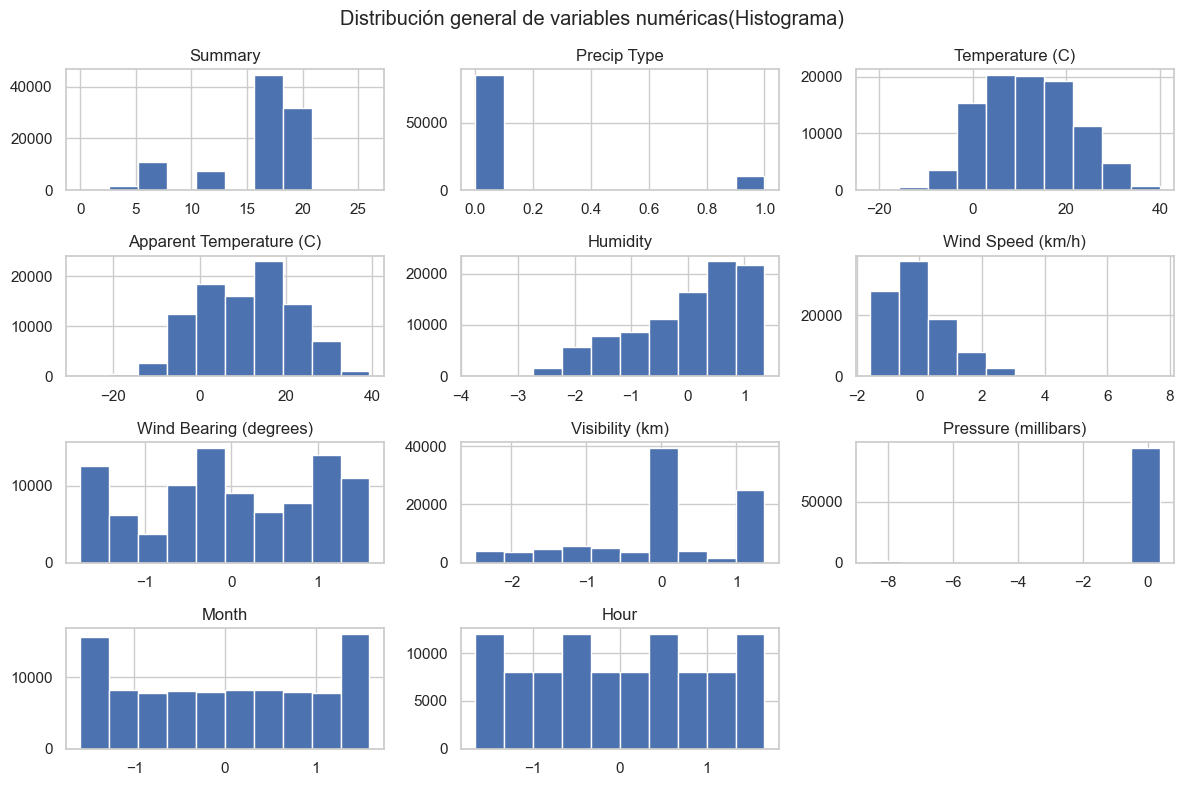

In [24]:
#Histograma
dt_WeatherHist.hist(figsize=(12,8))
plt.suptitle("Distribución general de variables numéricas(Histograma)")
plt.tight_layout()
plt.show()

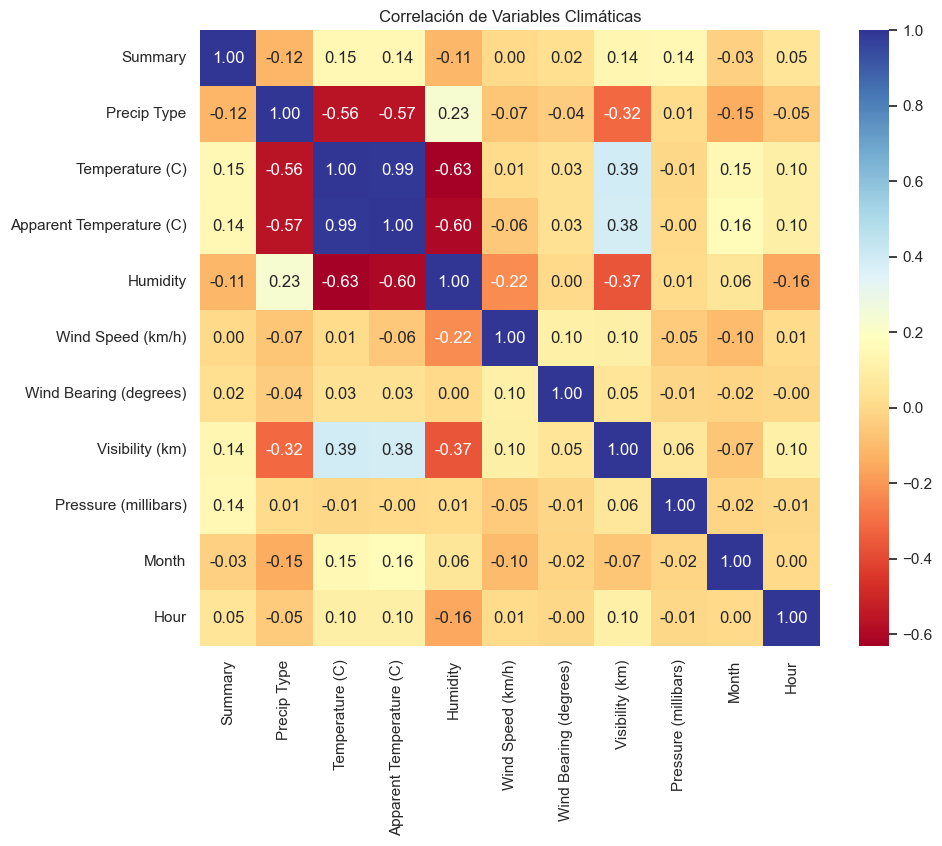

In [25]:
plt.figure(figsize=(10, 8))
# Calculamos la correlación solo de las columnas numéricas
sns.heatmap(dt_WeatherHist.corr(), annot=True, cmap='RdYlBu', fmt='.2f')
plt.title('Correlación de Variables Climáticas')
plt.show()

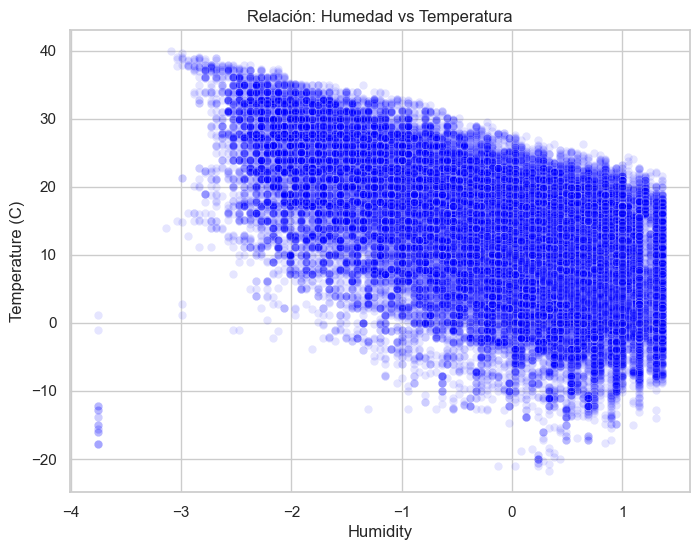

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Humidity', y='Temperature (C)', data=dt_WeatherHist, alpha=0.1, color='blue')
plt.title('Relación: Humedad vs Temperatura')
plt.grid(True)
plt.show()

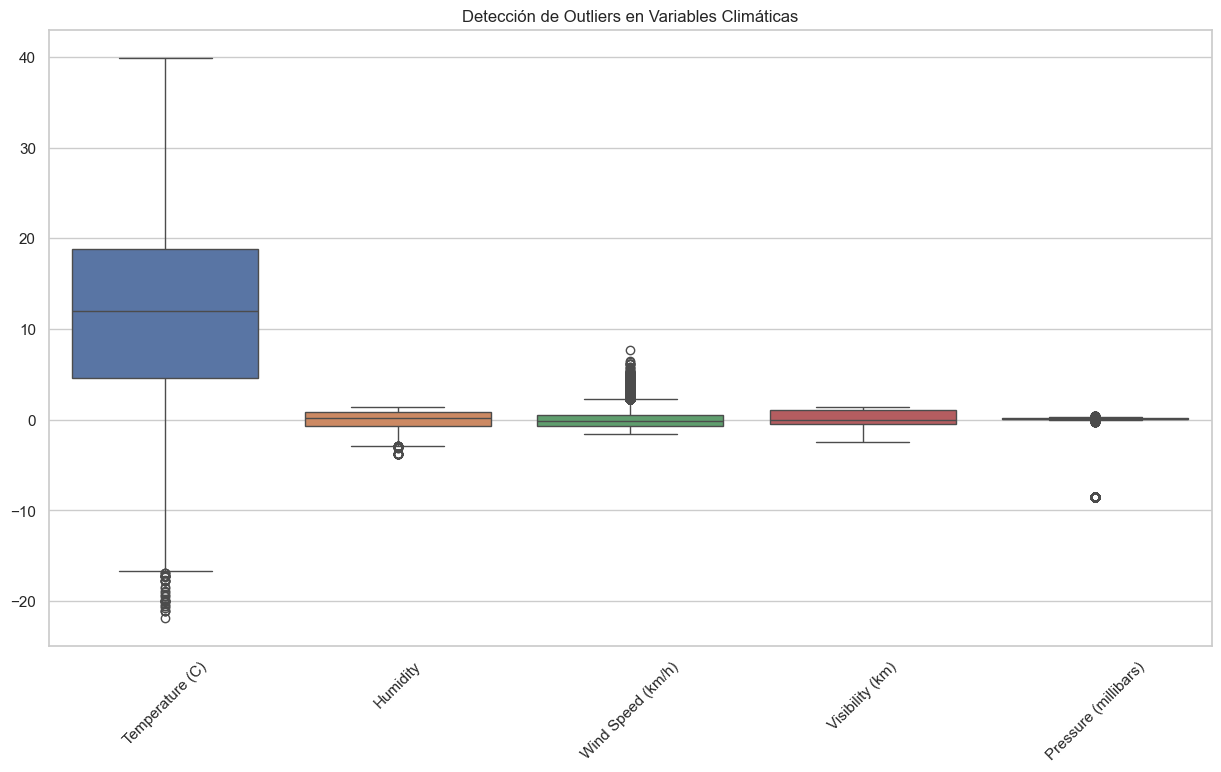

In [27]:
plt.figure(figsize=(15, 8))
# Seleccionamos las columnas numéricas principales para ver sus escalas y outliers
columnas_clima = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)']
sns.boxplot(data=dt_WeatherHist[columnas_clima])

plt.xticks(rotation=45)
plt.title("Detección de Outliers en Variables Climáticas")
plt.show()

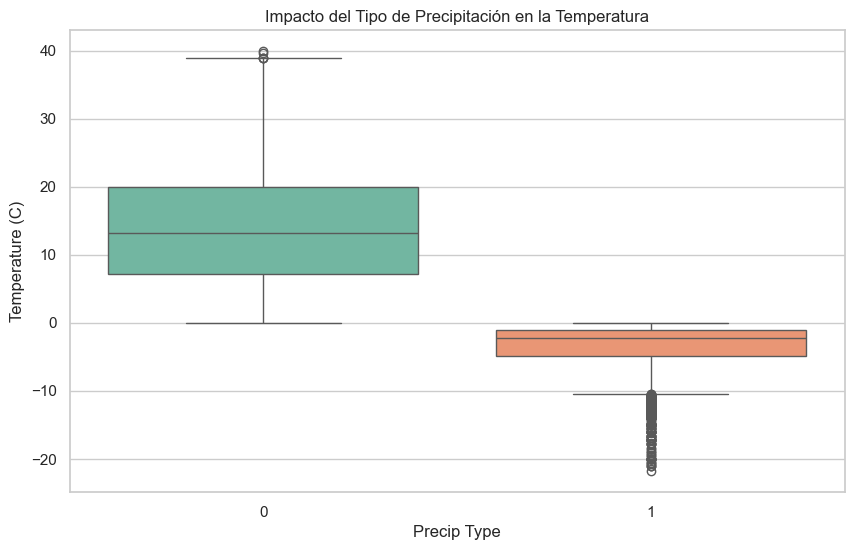

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Precip Type', y='Temperature (C)', data=dt_WeatherHist, palette='Set2', hue='Precip Type', legend=False)

plt.title("Impacto del Tipo de Precipitación en la Temperatura")
plt.xlabel("Precip Type")
plt.ylabel("Temperature (C)")
plt.show()

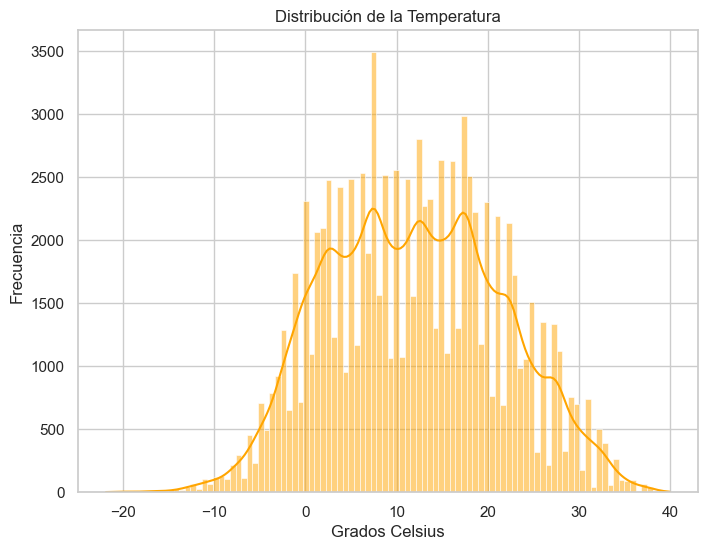

In [29]:
plt.figure(figsize=(8, 6))
sns.histplot(dt_WeatherHist['Temperature (C)'], kde=True, color='orange')
plt.title('Distribución de la Temperatura')
plt.xlabel('Grados Celsius')
plt.ylabel('Frecuencia')
plt.show()

## Hallazgos Weather History

Durante el análisis exploratorio preliminar del dataset Weather History, la variable objetivo **Temperature (C)** mostró una distribución amplia, con mayor concentración en rangos templados entre 0 °C y 20 °C, aunque también se observaron valores extremos cercanos a -20 °C y 40 °C, reflejando la diversidad climática del conjunto de datos.

En la etapa de limpieza y preprocesamiento se eliminaron las columnas *Loud Cover* y *Daily Summary*, debido a su baja relevancia analítica: la primera por su escasa variabilidad y la segunda por contener texto descriptivo poco útil para esta fase. Asimismo, la variable *Formatted Date* fue transformada en *Month* y *Hour*, permitiendo conservar la información temporal más relevante en un formato más preciso y útil para identificar patrones estacionales y horarios.

El análisis gráfico evidenció una relación inversa entre humedad y temperatura, donde mayores niveles de humedad tienden a asociarse con temperaturas más bajas. Además, el tipo de precipitación mostró diferencias claras en la distribución térmica, mientras que la detección de outliers identificó valores atípicos principalmente en temperatura, velocidad del viento y presión, consistentes con fenómenos meteorológicos extremos.